First, import the packages that you will need to use this notebook and mount your google drive if necessary.

In [ ]:
#Import Packages
import pandas as pd
import seaborn as sns
import numpy as np
from scipy.stats import norm

import time
import sys
import matplotlib.pyplot as plt
import math
import os

from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import MiniBatchKMeans
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Specify the path to your data.

Here, I will use a smaller portion of the dataset filtering for one donor and one unique region.

In [ ]:
# Specify the path to your CSV file
file_path = '/content/drive/MyDrive/Colab Notebooks/PanOrgan/05_25_HuBMAP_tunit.csv'

# Read the CSV file
df = pd.read_csv(file_path)
cells = df[df['donor'] == 'B004']
cells = cells[cells['unique_region'] == 'B004_Ascending']

copy_cells = cells.copy()

# Print the shape of the DataFrame (rows, columns)
print(cells.shape)

# Optionally, to view the first few rows of the file
print(cells.head())

<ipython-input-33-298aafdc5282>:5: DtypeWarning: Columns (62,63,70) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


(2512002, 80)
   Unnamed: 0      MUC2      SOX9      MUC1      CD31   Synapto     CD49f  \
0           0 -0.303994 -0.163727 -0.587608 -0.212903  0.164173 -0.664863   
1           1 -0.301927 -0.491706 -0.500804 -0.243205 -0.142568 -0.664861   
2           2 -0.302206 -0.547234 -0.510705 -0.235309 -0.217185 -0.622758   
3           3 -0.294644 -0.615593 -0.570580 -0.247548 -0.042246 -0.642230   
4           4 -0.298609 -0.272162 -0.587607 -0.228376 -0.266695 -0.664864   

       CD15      CHGA      CDX2  ...  machine  MUC6             Neighborhood  \
0  0.049305  0.003616 -0.377532  ...      NaN   NaN        Mature Epithelial   
1 -0.182627 -0.117573 -0.182754  ...      NaN   NaN  Transit Amplifying Zone   
2 -0.296486 -0.091504 -0.268055  ...      NaN   NaN   Innate Immune Enriched   
3 -0.299031 -0.121458 -0.377533  ...      NaN   NaN           Outer Follicle   
4 -0.237499 -0.121460 -0.168489  ...      NaN   NaN           Outer Follicle   

         Neighborhood_Ind   Neigh_sub  Nei

Now, we will perform neighborhood analysis on the subset of data. We will use defined functions to split the image into windows and specify the number of k nearest neighbors that we would like to use for our analysis.

In [ ]:
#Function for getting neighborhood windows
def get_windows(job, n_neighbors):

    # Unpack the job tuple containing start_time, idx, tissue_name, and indices
    start_time, idx, tissue_name, indices = job

    # Record the current time to measure the duration of the job
    job_start = time.time()

    # Print a message indicating the start of the job
    print("Starting:", str(idx+1)+'/'+str(len(exps)), ': ' + exps[idx])

    # Get the subset of the dataset for the specific tissue
    tissue = tissue_group.get_group(tissue_name)

    # Extract the coordinates (X, Y) for the points to be fitted from the tissue subset
    to_fit = tissue.loc[indices][[X, Y]].values

    # Fit the NearestNeighbors model on the tissue's X, Y coordinates
    fit = NearestNeighbors(n_neighbors=n_neighbors).fit(tissue[[X, Y]].values)

    # Find the nearest neighbors for the points in 'to_fit'
    m = fit.kneighbors(to_fit)

    # Sort the neighbors
    # 'args' are the indices that would sort the distances
    args = m[0].argsort(axis=1)

    # 'add' is used to adjust indices for flattened array
    add = np.arange(m[1].shape[0]) * m[1].shape[1]

    # Calculate sorted indices for neighbors
    sorted_indices = m[1].flatten()[args + add[:, None]]

    # Retrieve the neighbor indices from the tissue dataset
    neighbors = tissue.index.values[sorted_indices]

    # Record the end time of the job
    end_time = time.time()

    # Print a message indicating the end of the job and the duration
    print("Finishing:", str(idx+1)+"/"+str(len(exps)), ": "+ exps[idx], end_time - job_start, end_time - start_time)

    # Return the neighbor indices as an array of integers
    return neighbors.astype(np.int32)

The next few blocks of code will help the code find cellhier to run neighborhood analysis.

In [ ]:
cellhier_path = '/content/drive/MyDrive/Colab Notebooks/cellhier'
sys.path.append('/content/drive/MyDrive/Colab Notebooks/cellhier')
from general import *
from plot_john import *

Reset the dataframe index to ensure that neighborhood analysis can continue properly.

In [ ]:
cells.reset_index(inplace=True, drop=True)
print(cells)

         Unnamed: 0      MUC2      SOX9      MUC1      CD31   Synapto  \
0                 0 -0.303994 -0.163727 -0.587608 -0.212903  0.164173   
1                 1 -0.301927 -0.491706 -0.500804 -0.243205 -0.142568   
2                 2 -0.302206 -0.547234 -0.510705 -0.235309 -0.217185   
3                 3 -0.294644 -0.615593 -0.570580 -0.247548 -0.042246   
4                 4 -0.298609 -0.272162 -0.587607 -0.228376 -0.266695   
...             ...       ...       ...       ...       ...       ...   
2511997     2603100  0.251624 -0.360296 -0.254984 -0.229060  0.154796   
2511998     2603101 -0.274299 -0.465097 -0.367546 -0.210402 -0.204488   
2511999     2603102 -0.260292 -0.397157 -0.352751 -0.200957  0.427470   
2512000     2603103 -0.073782 -0.020896 -0.365204 -0.102411 -0.218278   
2512001     2603104 -0.269007 -0.494803 -0.256492 -0.253749 -0.196640   

            CD49f      CD15      CHGA      CDX2  ...    machine  MUC6  \
0       -0.664863  0.049305  0.003616 -0.377532  .

In [ ]:
# Define column names that will be used for neighborhood analysis
X = 'x'                  # Variable for the X coordinate
Y = 'y'                  # Variable for the Y coordinate
reg = 'unique_region'         # Variable for the filename or region identifier associated with coordinates
cluster_col = 'Cell Type'  # Variable for cell type/subtype classification

# List of columns to keep for analysis
keep_cols = [X, Y, reg, cluster_col]

In [ ]:
# Concatenate the original 'cells' DataFrame with dummy variables created from 'cluster_col'
# pd.get_dummies() converts categorical variable(s) into dummy/indicator variables
cells = pd.concat([cells, pd.get_dummies(cells[cluster_col])], axis=1)

# Get unique values from the 'cluster_col' column to use for summarization
sum_cols = cells[cluster_col].unique()

# Retrieve the values for these unique categories as a NumPy array
# This array can be used for further analysis or operations later for calculating the neighborhoods
values = cells[sum_cols].values

In [ ]:
#We can choose a range of nearest neighbors to calculate the neighborhoods
ks = [5,10,20] # k=5 means it collects 5 nearest neighbors for each center cell
n_neighbors = max(ks) #sets n_neighbors to max of the list that is set

In [ ]:
# Group the cell data by region
# 'cells' is a DataFrame containing cell data
# 'tissue_group' will be a GroupBy object with cells grouped by the 'reg' column (representing regions)
tissue_group = cells[[X, Y, reg]].groupby(reg)

# Get a list of unique regions (filenames)
# 'exps' will contain all unique region names found in the 'reg' column of the 'cells' DataFrame
exps = list(cells[reg].unique())

# Prepare chunks of data for processing
# 'tissue_chunks' is a list of tuples, each tuple representing a job for processing
# Each tuple contains the current time, index of the region in 'exps', the region name, and a subset of indices
# 'np.array_split(indices, 1)' splits the indices for each group into chunks (1 chunk in this case)
# This loop goes through each group in 'tissue_group', and for each group, it creates a job tuple
tissue_chunks = [(time.time(), exps.index(t), t, a) for t, indices in tissue_group.groups.items() for a in np.array_split(indices, 1)]

# Process each job to get the windows (neighbors of the cells)
# 'tissues' is a list of results from the 'get_windows' function
# The 'get_windows' function is applied to each job in 'tissue_chunks'
# 'n_neighbors' is a parameter for the 'get_windows' function, defining the number of neighbors to consider
tissues = [get_windows(job, n_neighbors) for job in tissue_chunks]

Starting: 1/64 : B004_Ascending
Finishing: 1/64 : B004_Ascending 0.1495051383972168 0.15262889862060547
Starting: 9/64 : B004_Descending
Finishing: 9/64 : B004_Descending 0.15251922607421875 0.3056182861328125
Starting: 49/64 : B004_Descending - Sigmoid
Finishing: 49/64 : B004_Descending - Sigmoid 0.11671209335327148 0.42296409606933594
Starting: 17/64 : B004_Duodenum
Finishing: 17/64 : B004_Duodenum 0.2141590118408203 0.6376793384552002
Starting: 25/64 : B004_Ileum
Finishing: 25/64 : B004_Ileum 0.1285707950592041 0.7671284675598145
Starting: 34/64 : B004_Mid-jejunum
Finishing: 34/64 : B004_Mid-jejunum 0.16919612884521484 0.9368577003479004
Starting: 41/64 : B004_Proximal Jejunum
Finishing: 41/64 : B004_Proximal Jejunum 0.15338778495788574 1.0910751819610596
Starting: 57/64 : B004_Transverse
Finishing: 57/64 : B004_Transverse 0.18835139274597168 1.2800860404968262
Starting: 2/64 : B005_Ascending
Finishing: 2/64 : B005_Ascending 0.09434247016906738 1.3752367496490479
Starting: 10/64 : B

In [ ]:
# Initialize a dictionary to store the output
out_dict = {}

# Loop over a list of values 'ks' (different numbers of neighbors to consider)
for k in ks:
    # Iterate over each tissue's neighbors and the corresponding job information
    for neighbors, job in zip(tissues, tissue_chunks):

        # Create an array of indices for the current chunk of data
        chunk = np.arange(len(neighbors))  # equivalent to 0, 1, 2, ..., len(neighbors)-1

        # Extract the tissue name and indices from the job tuple
        tissue_name = job[2]  # Region/filename from the job tuple
        indices = job[3]      # Indices from the job tuple

        # Compute the 'window' - a summary measure for the neighborhood of each cell up to the k-th neighbor
        # Reshape and sum values to get a compact representation of neighborhood information
        window = values[neighbors[chunk, :k].flatten()].reshape(len(chunk), k, len(sum_cols)).sum(axis=1)

        # Store the computed window and indices in the output dictionary
        # Keyed by a tuple of (tissue_name, k)
        out_dict[(tissue_name, k)] = (window.astype(np.float16), indices)

# Initialize a dictionary to store the final windows data
windows = {}

# Iterate over each value of k again to process the stored information
for k in ks:

    # Concatenate data for each experiment ('exp') into a DataFrame
    # This DataFrame contains the window data for each cell, indexed by cell indices, for the current value of k
    window = pd.concat([pd.DataFrame(out_dict[(exp, k)][0], index=out_dict[(exp, k)][1].astype(int), columns=sum_cols) for exp in exps], axis=0)

    # Ensure the window data is in the same order as the original cells DataFrame
    window = window.loc[cells.index.values]

    # Concatenate the window data with the original columns specified in 'keep_cols'
    window = pd.concat([cells[keep_cols], window], axis=1)

    # Store the concatenated DataFrame in the 'windows' dictionary, keyed by the current value of k
    windows[k] = window


In [ ]:
#Choose k value to analyze and pull out from dictionary of stored results of vectors
k = 10
windows2 = windows[k]
#Add cell type column to output windows dataframe
windows2[cluster_col] = cells[cluster_col]

In [ ]:
windows2

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,x,y,unique_region,Cell Type,NK,Enterocyte,MUC1+ Enterocyte,TA,CD66+ Enterocyte,Paneth,...,B,Neutrophil,Endothelial,Cycling TA,Plasma,CD4+ T cell,Stroma,Nerve,ICC,CD7+ Immune
0,3984.0,3387.0,B004_Ascending,NK,1.0,6.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,5188.0,4116.0,B004_Ascending,NK,1.0,6.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,6070.0,3146.0,B004_Ascending,NK,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,4.0,0.0
3,6792.0,3891.0,B004_Ascending,NK,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,5.0,0.0,0.0,0.0,0.0
4,7968.0,6351.0,B004_Ascending,NK,1.0,0.0,0.0,0.0,0.0,0.0,...,3.0,0.0,0.0,1.0,0.0,5.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2511997,7633.0,353.0,B008_Trans,DC,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,2.0,0.0,0.0,0.0,1.0,3.0,2.0,0.0
2511998,4921.0,533.0,B008_Trans,DC,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,7.0,0.0,0.0,0.0
2511999,3710.0,6049.0,B008_Trans,DC,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0
2512000,5823.0,794.0,B008_Trans,DC,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,5.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0


At the end of neighborhood analysis we have a dataframe containing each cell, its x and y coordinates, unique region, cell type, and counts of the cell types of their nearest neighbors. We will now use this dataframe to use mixture models to assign probabilities that a cell belongs to already annotated neighborhoods from the dataset.

Calculate Means and Standard Deviations for Cell Type Vector Features

In [ ]:
windows2.columns

Index(['x', 'y', 'unique_region', 'Cell Type', 'NK', 'Enterocyte',
       'MUC1+ Enterocyte', 'TA', 'CD66+ Enterocyte', 'Paneth', 'Smooth muscle',
       'M1 Macrophage', 'Goblet', 'Neuroendocrine', 'CD57+ Enterocyte',
       'Lymphatic', 'CD8+ T', 'DC', 'M2 Macrophage', 'B', 'Neutrophil',
       'Endothelial', 'Cycling TA', 'Plasma', 'CD4+ T cell', 'Stroma', 'Nerve',
       'ICC', 'CD7+ Immune'],
      dtype='object')

In [ ]:
filtered_cells = copy_cells # make a copy of the original annotated dataset to ensure that we do not write over top of it
filtered_cells.reset_index(inplace=True, drop=True) # reset the index to ensure that it matches the index of our dataframe following neighborhood analysis

We need to ensure that the neighborhood analysis dataframe is in a format that allows for rounding that will result in real values when we calculate mean and standard deviation of the annotated neighborhood centroids. Type 'float32' should be sufficient based on previous investigation.

In [ ]:
# List of cell type columns
cell_type_columns = ['DC', 'Stroma', 'Plasma', 'CD4+ T cell', 'M2 Macrophage', 'M1 Macrophage', 'ICC', 'B', 'NK',
                     'CD66+ Enterocyte', 'Smooth muscle', 'Neuroendocrine', 'Lymphatic', 'Cycling TA', 'Enterocyte',
                     'MUC1+ Enterocyte', 'Paneth', 'CD8+ T', 'Endothelial', 'Neutrophil', 'Goblet', 'TA', 'Nerve',
                     'CD7+ Immune', 'CD57+ Enterocyte']
windows2[cell_type_columns] = windows2[cell_type_columns].astype('float32')

Now, we will loop through each neighborhood, filter the annotated dataset for cells that belong to this neighborhood, and calculate the mean and standard deviation for each of the nearest neighbor cell type vectors. This will return a dataframe with neighborhoods as rows and columns with a cell type feature mean and standard deviation for each of the possible cell types in the nearest neighbor vectors.

In [ ]:
# List of neighborhoods to loop through
neighborhoods_to_loop = ['Innate Immune Enriched', 'Outer Follicle', 'Plasma Cell Enriched',
 'Transit Amplifying Zone', 'Adaptive Immune Enriched', 'Stroma',
 'Paneth Enriched', 'Smooth Muscle & Innate Immune', 'Mature Epithelial',
 'Microvasculature', 'CD8+ T Enriched IEL', 'Stroma & Innate Immune',
 'Macrovasculature', 'Innervated Stroma', 'Secretory Epithelial',
 'Innervated Smooth Muscle', 'Smooth Muscle', 'Glandular Epithelial',
 'CD66+ Mature Epithelial', 'Inner Follicle']  # Replace with actual neighborhoods

# List of cell type columns to compute mean and std for
cell_type_columns = ['DC', 'Stroma', 'Plasma', 'CD4+ T cell', 'M2 Macrophage', 'M1 Macrophage', 'ICC', 'B', 'NK',
                     'CD66+ Enterocyte', 'Smooth muscle', 'Neuroendocrine', 'Lymphatic', 'Cycling TA', 'Enterocyte',
                     'MUC1+ Enterocyte', 'Paneth', 'CD8+ T', 'Endothelial', 'Neutrophil', 'Goblet', 'TA', 'Nerve',
                     'CD7+ Immune', 'CD57+ Enterocyte']

# Create an empty list to store the results for each neighborhood
all_results = []

# Loop through each neighborhood
for neighborhood in neighborhoods_to_loop:
    # Step 1: Filter df1 by the specific neighborhood
    filtered_neighborhood_df = filtered_cells[filtered_cells['Neighborhood'] == neighborhood]

    # Step 2: Extract the cell numbers from the filtered rows
    cell_numbers_in_neighborhood = filtered_neighborhood_df.index.values

    # Step 3: Find matching cell numbers in df2
    matching_cells_df = windows2[windows2.index.isin(cell_numbers_in_neighborhood)]

    # Create a dictionary to store the mean and std for the current neighborhood
    mean_std_results = {'Neighborhood': neighborhood}

    # Step 4: Calculate mean and std for each cell type column
    for column in cell_type_columns:
        if column in matching_cells_df.columns:
            column_mean = matching_cells_df[column].mean()
            column_std = matching_cells_df[column].std()
            mean_std_results[f'{column}_mean'] = column_mean
            mean_std_results[f'{column}_std'] = column_std

    # Append the results for this neighborhood to the all_results list
    all_results.append(mean_std_results)

# Step 5: Create a DataFrame from the results list
results_df = pd.DataFrame(all_results)

# Print the resulting DataFrame
print(results_df)

                     Neighborhood   DC_mean    DC_std  Stroma_mean  \
0          Innate Immune Enriched  0.820026  1.326329     0.566463   
1                  Outer Follicle  0.389051  0.810012     0.469491   
2            Plasma Cell Enriched  0.184558  0.519762     0.424214   
3         Transit Amplifying Zone  0.067702  0.305675     0.273827   
4        Adaptive Immune Enriched  0.356891  0.763123     0.483883   
5                          Stroma  0.082569  0.357364     5.411641   
6                 Paneth Enriched  0.081000  0.321540     0.272249   
7   Smooth Muscle & Innate Immune  0.111399  0.396732     0.467310   
8               Mature Epithelial  0.012802  0.122125     0.145057   
9                Microvasculature  0.147253  0.469073     0.902058   
10            CD8+ T Enriched IEL  0.035004  0.221597     0.165920   
11         Stroma & Innate Immune  0.115149  0.404196     1.950120   
12               Macrovasculature  0.083343  0.333936     0.774405   
13              Inne

In [ ]:
# Save centroid results as CSV
results_df.to_csv('/content/drive/MyDrive/Colab Notebooks/PanOrgan/Mixture Model/all_neighborhood_centroids', index=False)

Hard Coded Mixture Model

The algorithm below will initialize a gaussian mixture model to have the same number of centroids with means and standard deviations that were calculated above for the k nearest neighbor vectors for each neighborhood. Then, it will loop through each cell and calculate the posterior probability for each nearest neighbor cell type feature of that cell and compare it to each of the defined neighborhood centroids. The total probability that a cell belongs to a neighborhood cluster is the multiplied probabilities of each of the nearest neighbor cell type features in the vector. This is repeated for each cell in the dataframe.

In [ ]:
# Load initial cluster centroids (means and stds)
df_centroids = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/PanOrgan/Mixture Model/all_neighborhood_centroids").dropna()

In [ ]:
df_centroids

,Neighborhood,DC_mean,DC_std,Stroma_mean,Stroma_std,Plasma_mean,Plasma_std,CD4+ T cell_mean,CD4+ T cell_std,M2 Macrophage_mean,...,Goblet_mean,Goblet_std,TA_mean,TA_std,Nerve_mean,Nerve_std,CD7+ Immune_mean,CD7+ Immune_std,CD57+ Enterocyte_mean,CD57+ Enterocyte_std
0,Innate Immune Enriched,0.820026,1.326329,0.566463,0.781409,0.259431,0.554993,0.588793,0.749166,0.614087,...,0.223242,0.534438,0.061831,0.268551,0.374706,0.652983,0.018671,0.150631,0.011087,0.169479
1,Outer Follicle,0.389051,0.810012,0.469491,0.749827,0.547095,0.875195,3.978493,1.252346,0.442613,...,0.117190,0.412308,0.038813,0.222895,0.287062,0.602767,0.027587,0.180272,0.003126,0.062712
2,Plasma Cell Enriched,0.184558,0.519762,0.424214,0.713189,3.361492,1.897615,0.808408,0.878842,0.537420,...,0.307855,0.626644,0.072089,0.288747,0.221771,0.506632,0.013134,0.133899,0.005040,0.094992
3,Transit Amplifying Zone,0.067702,0.305675,0.273827,0.615373,0.200390,0.528466,0.236999,0.542600,0.158802,...,0.973421,1.017011,1.005133,1.377471,0.091261,0.331030,0.045461,0.300079,0.019721,0.185911
4,Adaptive Immune Enriched,0.356891,0.763123,0.483883,0.724286,0.673187,0.900739,1.217730,0.902141,0.638816,...,0.172269,0.438984,0.075646,0.306958,0.388697,0.680248,0.028951,0.200728,0.004642,0.084072
5,Stroma,0.082569,0.357364,5.411641,1.862382,0.090867,0.395695,0.214483,0.548811,1.128827,...,0.027351,0.205576,0.011700,0.120457,0.276459,0.660861,0.006262,0.085719,0.001962,0.053189
6,Paneth Enriched,0.081000,0.321540,0.272249,0.574322,0.097564,0.360111,0.483098,0.743743,0.180993,...,0.427400,0.793310,0.180251,0.491962,0.205249,0.505803,0.008333,0.109120,0.023919,0.194041
7,Smooth Muscle & Innate Immune,0.111399,0.396732,0.467310,0.511627,0.201164,0.616439,0.344436,0.694859,0.723343,...,0.068654,0.328227,0.039812,0.224394,1.089242,1.145622,0.005882,0.084324,0.002382,0.065073
8,Mature Epithelial,0.012802,0.122125,0.145057,0.420052,0.059435,0.291122,0.066965,0.281985,0.029326,...,0.469396,0.749173,0.161334,0.455706,0.014356,0.127893,0.051891,0.273563,0.007344,0.094708
9,Microvasculature,0.147253,0.469073,0.902058,1.072520,0.146255,0.437493,0.386470,0.708685,0.754366,...,0.071661,0.333326,0.023262,0.178003,0.196977,0.510948,0.008844,0.101218,0.003484,0.086790


This code will show the number of standard deviation values that are zero. These values will be in the denominator and will impact your final probability calculations (for an entire dataset, there should be 0 of these values, but with subsets of the data, there may be a few of these values).

In [ ]:
# Count the number of zero standard deviation values in df_centroids
zero_std_counts = (df_centroids.filter(regex='_std$') == 0).sum().sum()

print(f"Number of zero standard deviation values: {zero_std_counts}")

Number of zero standard deviation values: 0


Importantly in the next step below, we assume that when the standard deviation value for the centroid is zero, if the cell type vector value for a cell is equal to the mean then probability is 1. This means that if the value is not equal to the mean, the probability is 0.

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import norm
from multiprocessing import Pool, cpu_count
from tqdm import tqdm

# List of neighborhoods to loop through (already provided)
neighborhoods_to_loop = [
    'Innate Immune Enriched', 'Outer Follicle', 'Plasma Cell Enriched',
    'Transit Amplifying Zone', 'Adaptive Immune Enriched', 'Stroma',
    'Paneth Enriched', 'Smooth Muscle & Innate Immune', 'Mature Epithelial',
    'Microvasculature', 'CD8+ T Enriched IEL', 'Stroma & Innate Immune',
    'Macrovasculature', 'Innervated Stroma', 'Secretory Epithelial',
    'Innervated Smooth Muscle', 'Smooth Muscle', 'Glandular Epithelial',
    'CD66+ Mature Epithelial', 'Inner Follicle'
]

# List of cell types (already provided)
cell_type_features = [
    'NK', 'Enterocyte', 'MUC1+ Enterocyte', 'TA', 'CD66+ Enterocyte', 'Paneth', 'Goblet',
    'Neuroendocrine', 'CD57+ Enterocyte', 'Smooth muscle', 'Lymphatic',
    'CD8+ T', 'DC', 'M2 Macrophage', 'M1 Macrophage', 'B', 'Neutrophil',
    'Endothelial', 'Cycling TA', 'Plasma', 'CD4+ T cell', 'Stroma', 'Nerve',
    'ICC', 'CD7+ Immune'
]

# Function to calculate probabilities for a single cell
def calculate_probabilities_for_cell(args):
    cell_data, df_centroids, cell_type_features = args  # Unpack the arguments

    neighborhood_probs = {}

    # Loop through each neighborhood (each row in df_centroids)
    for _, centroid_row in df_centroids.iterrows():
        neighborhood_name = centroid_row['Neighborhood']
        total_prob = 1

        # For each cell type in the list, calculate the probability
        for cell_type in cell_type_features:
            mean_col = f'{cell_type}_mean'
            std_col = f'{cell_type}_std'

            if mean_col in centroid_row and std_col in centroid_row:
                mean = centroid_row[mean_col]
                std = centroid_row[std_col]

                # Get the value of the current cell for this cell type (nearest neighbor count)
                cell_value = cell_data.get(cell_type, np.nan)

                # If std is zero, check if the cell value matches the mean
                if std == 0:
                    if cell_value == mean:
                        cell_prob = 1
                    else:
                        cell_prob = 0
                else:
                    # Otherwise, calculate the probability using the normal distribution (PDF)
                    cell_prob = norm.pdf(cell_value, loc=mean, scale=std)

                # Multiply the probability for this cell type to the total probability
                total_prob *= cell_prob

        # Store the total probability for the current neighborhood
        neighborhood_probs[neighborhood_name] = total_prob

    # Normalize the probabilities across all neighborhoods so they sum to 1
    total_prob_sum = sum(neighborhood_probs.values())
    for neighborhood in neighborhood_probs:
        neighborhood_probs[neighborhood] /= total_prob_sum

    return neighborhood_probs

# Function to parallelize the calculations across all cells
def parallelize_probability_calculations(windows2, df_centroids, cell_type_features):
    # Use all available CPUs for parallel processing
    num_processes = cpu_count()

    # Create a pool of workers
    with Pool(num_processes) as pool:
        # Use tqdm to display progress bar
        results = list(tqdm(pool.imap(
            calculate_probabilities_for_cell,  # Pass the function directly
            [(windows2.loc[cell_index], df_centroids, cell_type_features) for cell_index in windows2.index]), total=len(windows2)))

    return results

# Call the parallelization function
probabilities_list = parallelize_probability_calculations(windows2, df_centroids, cell_type_features)

# Convert the results into a DataFrame
probabilities_df = pd.DataFrame(probabilities_list, index=windows2.index)

# Print or save the resulting probabilities DataFrame
print(probabilities_df)

 18%|█▊        | 458380/2512002 [2:59:09<13:24:42, 42.53it/s]

This code will output the distributions of probabilities for each of the cells in the neighborhoods.

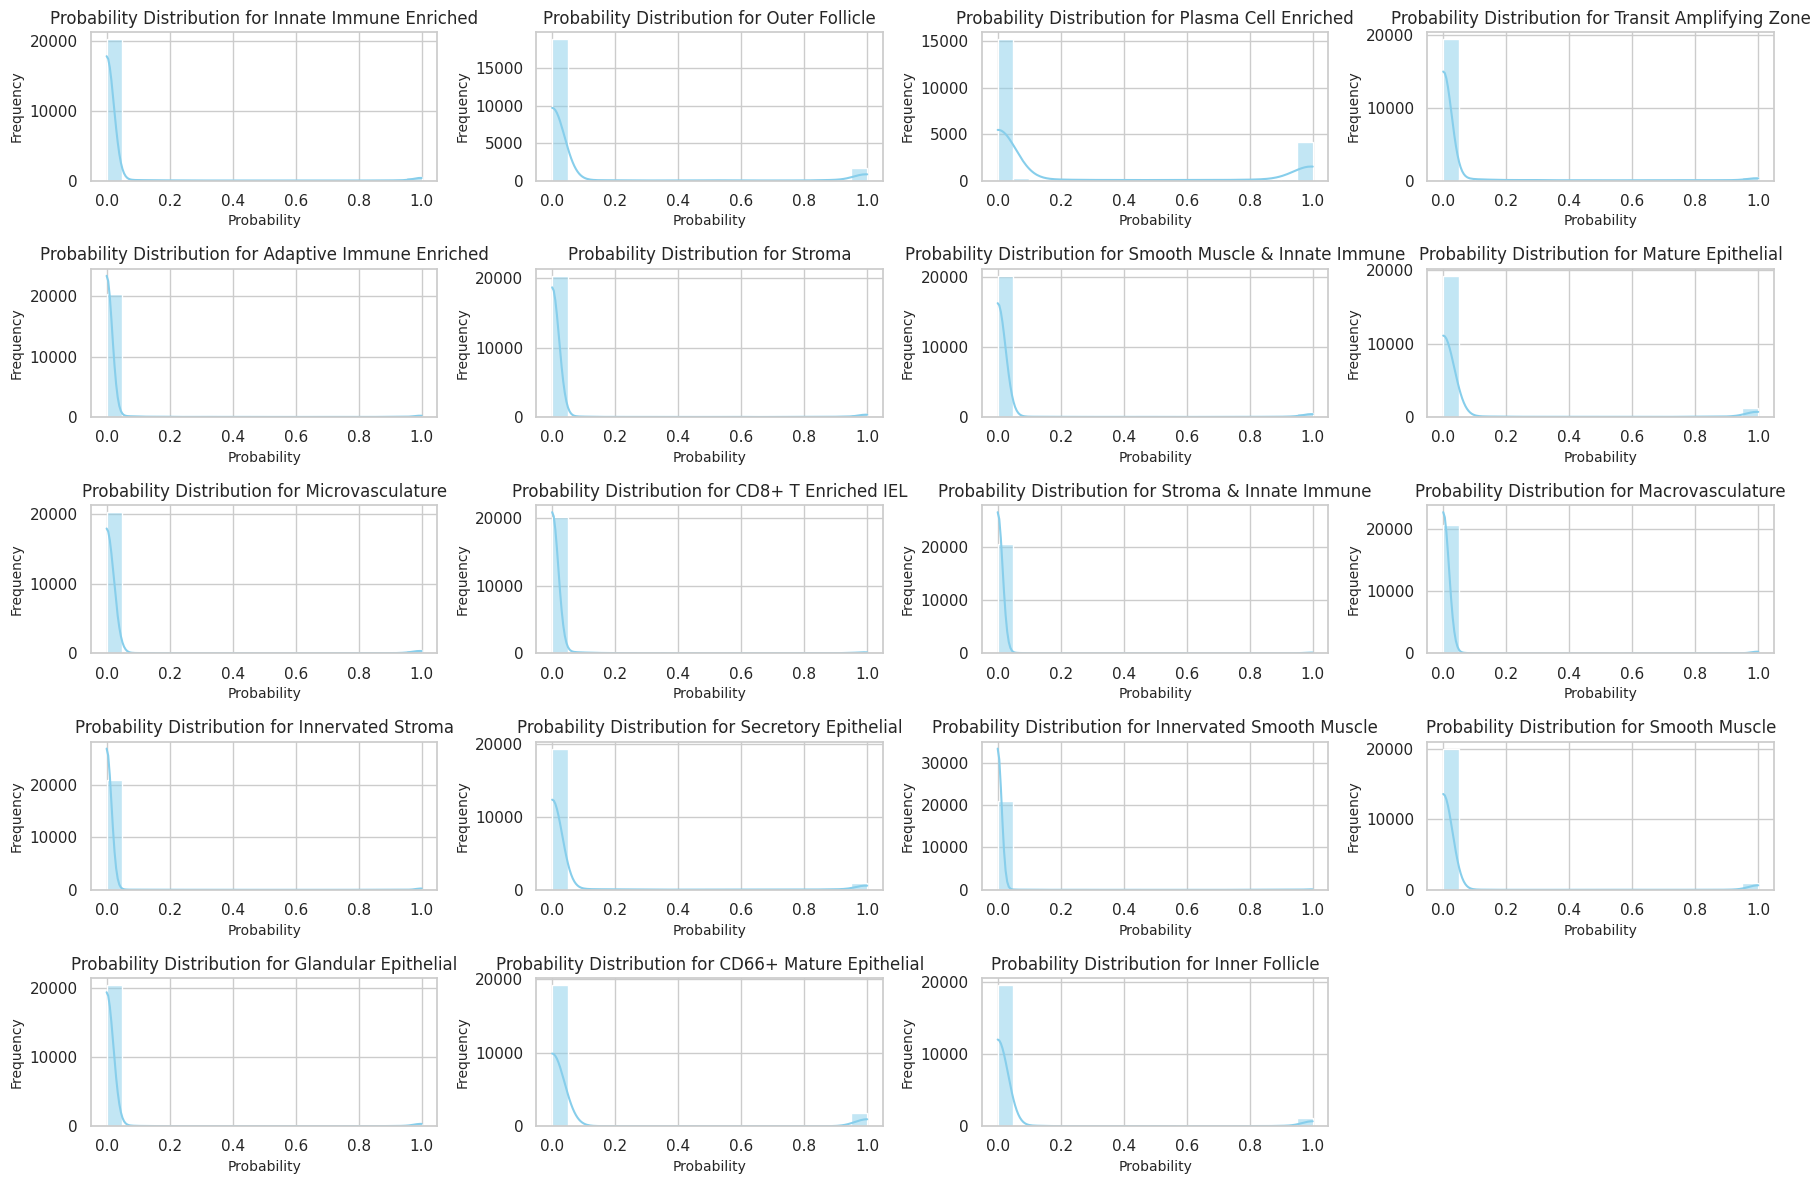

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the plot style and figure size
sns.set(style="whitegrid")
plt.figure(figsize=(18, 12))  # Adjust the size to fit all panels

# Number of neighborhoods
num_neighborhoods = len(probabilities_df.columns)

# Create subplots: Number of rows and columns (adjust as needed)
ncols = 4  # Number of columns for the panels (feel free to adjust)
nrows = (num_neighborhoods // ncols) + (num_neighborhoods % ncols != 0)  # Automatically determine the number of rows

# Loop through each neighborhood and plot its probability distribution
for i, neighborhood in enumerate(probabilities_df.columns):
    ax = plt.subplot(nrows, ncols, i + 1)

    # Plot the distribution of probabilities for the current neighborhood
    sns.histplot(probabilities_df[neighborhood], kde=True, ax=ax, color="skyblue", bins=20)

    # Set the title and labels
    ax.set_title(f"Probability Distribution for {neighborhood}", fontsize=12)
    ax.set_xlabel('Probability', fontsize=10)
    ax.set_ylabel('Frequency', fontsize=10)

# Adjust layout to ensure plots don't overlap
plt.tight_layout()

# Show the plot
plt.show()


This code will plot the assigned neighborhood probability of the cells on the x and y axis using the assigned neighborhood from the original dataset and the probability calculated from the hard coded mixture model.

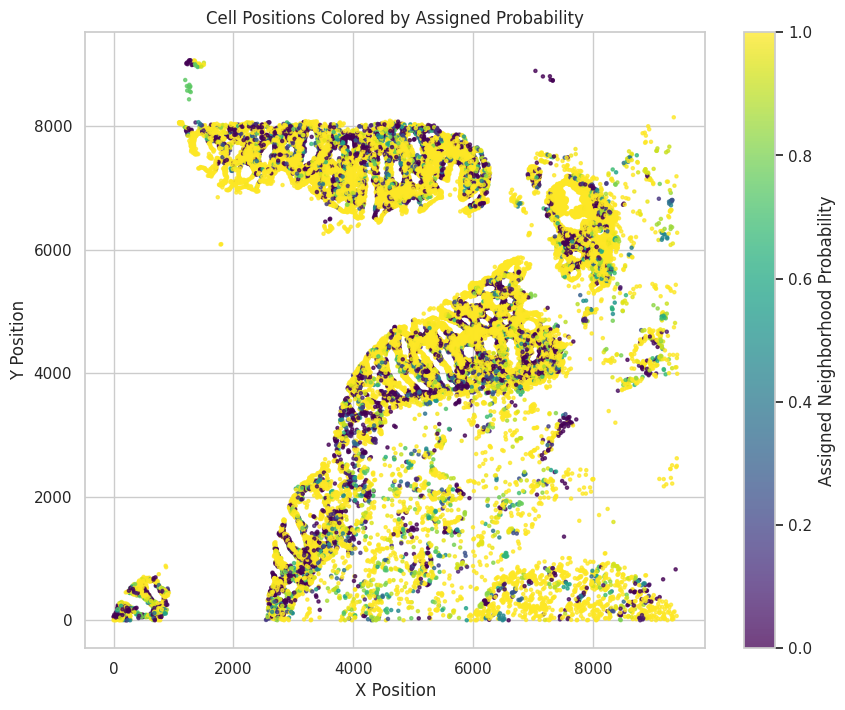

In [ ]:
import matplotlib.pyplot as plt

# Step 1: Retrieve assigned neighborhoods
assigned_neighborhoods = filtered_cells['Neighborhood']

# Step 2: Extract the probability corresponding to each cell's assigned neighborhood
assigned_probabilities = probabilities_df.reindex(filtered_cells.index).apply(
    lambda row: row[filtered_cells.loc[row.name, 'Neighborhood']], axis=1
)

# Step 3: Create a new DataFrame to store x, y, assigned neighborhood, and probability
visualization_df = pd.DataFrame({
    'x': filtered_cells['x'],
    'y': filtered_cells['y'],
    'assigned_neighborhood': assigned_neighborhoods,
    'assigned_probability': assigned_probabilities
})

# Step 4: Plot cells based on x and y, colored by assigned probability
plt.figure(figsize=(10, 8))
sc = plt.scatter(
    visualization_df['x'],
    visualization_df['y'],
    c=visualization_df['assigned_probability'],
    cmap='viridis',
    alpha=0.75,
    s=5
)
plt.colorbar(sc, label="Assigned Neighborhood Probability")
plt.xlabel('X Position')
plt.ylabel('Y Position')
plt.title('Cell Positions Colored by Assigned Probability')
plt.show()


It can be seen here that compared to the other two methods used with scikit learn, this method does not allow for the centroids to update, and therefore there are more cells with lower probabilities in their assigned clusters. Also, an "edge" can be seen where the inner and outer follicle neighborhoods meet which is a good sign for future analysis of anatomical and cluster edges!